In [2]:
import pandas as pd

In [3]:
gold_dataset = pd.read_csv("Gold vs USDINR.csv")

In [4]:
gold_dataset.head()

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,"₹5,066.31"
1,2024-01-08,83.076103,"₹4,966.31"
2,2024-01-15,83.160599,"₹5,015.33"
3,2024-01-22,83.146103,"₹4,950.84"
4,2024-01-29,82.927597,"₹4,976.77"


In [5]:
gold_dataset['Goldrate'] = gold_dataset['Goldrate']\
    .str.replace('₹', '', regex=True)\
    .str.replace(',', '', regex=True)\
    .astype(float)


<Axes: ylabel='USD_INR'>

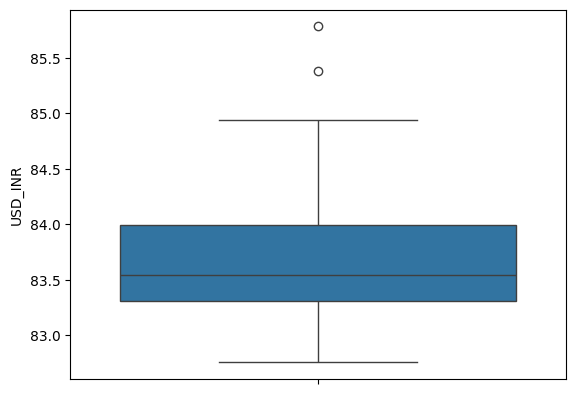

In [6]:
import seaborn as sns
sns.boxplot(gold_dataset['USD_INR'])

<Axes: xlabel='USD_INR', ylabel='Goldrate'>

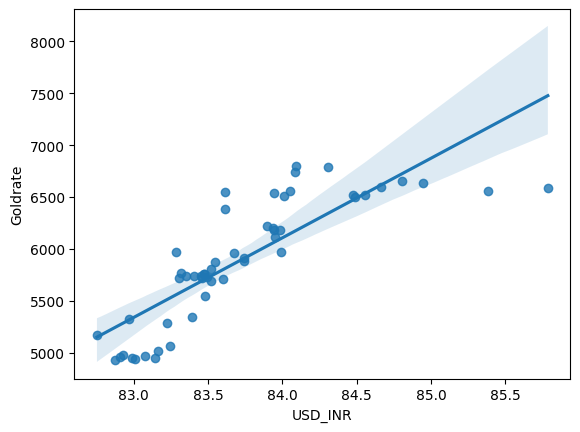

In [7]:
sns.regplot(x='USD_INR', y='Goldrate', data=gold_dataset)

In [8]:
x = gold_dataset[['USD_INR']]
y= gold_dataset[['Goldrate']]

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42)


In [10]:
 x_train.shape,x_test.shape

((47, 1), (6, 1))

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [12]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [34]:
x_train_scaled

array([[-0.4753469 ],
       [ 1.91603897],
       [-0.87974106],
       [ 0.36700952],
       [-0.36423189],
       [-1.24606136],
       [-0.33998365],
       [-1.09189238],
       [ 0.28432837],
       [-1.21933493],
       [-0.15146399],
       [-0.17182302],
       [ 0.92354506],
       [ 0.35503362],
       [ 1.69379708],
       [-0.25979254],
       [-1.49178076],
       [-0.63775672],
       [ 0.04932799],
       [ 0.34602205],
       [-0.40604082],
       [-0.7546344 ],
       [-0.7328762 ],
       [ 1.20624748],
       [-0.30097304],
       [ 0.43025651],
       [ 0.461963  ],
       [ 0.05011057],
       [ 1.18371856],
       [-0.98853205],
       [-0.60807784],
       [-0.85721215],
       [ 0.36342862],
       [ 0.42186152],
       [-0.29537637],
       [ 1.48242836],
       [-1.16027359],
       [-0.371536  ],
       [-0.39283176],
       [ 3.22402082],
       [-0.66169667],
       [-1.30527686],
       [ 0.57448905],
       [-0.56394486],
       [-0.05883454],
       [ 2

In [13]:
from sklearn.linear_model import LinearRegression
regressor  = LinearRegression()

In [14]:
regressor.fit(x_train_scaled,y_train)

LinearRegression()

In [15]:
m = regressor.coef_[0][0]
b = regressor.intercept_[0]
m,b

(np.float64(469.2075576153299), np.float64(5878.573404255313))

In [16]:
x_train_predict = regressor.predict(x_train_scaled)

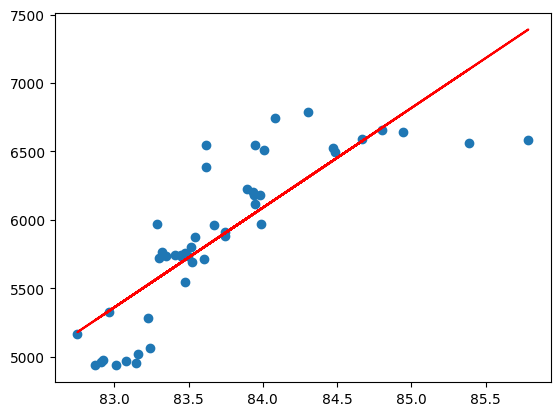

In [17]:
import matplotlib.pyplot as plt
plt.scatter(x_train,y_train)
plt.plot(x_train, x_train_predict, color='r')
plt.show()

In [18]:
x_test_predicted = regressor.predict(x_test_scaled)

In [19]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, x_test_predicted)

np.float64(141948.22993388725)

In [20]:
from sklearn.model_selection import RandomizedSearchCV
param_space = {'copy_X' : [True,False],
               'fit_intercept' : [True, False],
               'n_jobs':[1,5,10,None],
               'positive' : [True, False]}

In [21]:
search = RandomizedSearchCV(regressor, param_space , n_iter =50,cv =5)
search.fit(x_train,y_train)

C:\Users\Kumara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 32 is smaller than n_iter=50. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=LinearRegression(), n_iter=50,
                   param_distributions={'copy_X': [True, False],
                                        'fit_intercept': [True, False],
                                        'n_jobs': [1, 5, 10, None],
                                        'positive': [True, False]})

In [22]:
search.best_params_

{'positive': False, 'n_jobs': 1, 'fit_intercept': True, 'copy_X': True}

In [23]:
tuned_model = LinearRegression(positive= False, n_jobs= 1, fit_intercept= True, copy_X= True)

In [24]:
tuned_model.fit(x_train_scaled, y_train)

LinearRegression(n_jobs=1)

In [25]:
tuned_model.coef_
tuned_model.intercept_

array([5878.57340426])

In [26]:
import pickle

In [27]:
pickle.dump(regressor,open('reg.pkl' ,'wb'))

In [28]:

regressor_reloaded = pickle.load(open('reg.pkl', 'rb'))
regressor_reloaded.coef_

array([[469.20755762]])

In [29]:
pickle.dump(scaler, open('scaler.pkl' ,'wb'))

In [30]:
import sys
!{sys.executable} -m pip install gradio



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: C:\Users\Kumara\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [33]:
import gradio as gr
import numpy as np


demo = gr.Interface(
    fn =calculate,
    inputs = ["number"],
    outputs = ["number"],
    title ="gold rate"
)
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


C:\Users\Kumara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [32]:
def calculate(usd_inr):
    scaled_input = scaler.transform(np.array(usd_inr).reshape(1,-1))
    return regressor.predict(scaled_input)[0][0].round(2)
                                    